# Handwritten Digit Recognition using LeNet-5 and MNIST
This notebook implements the classic **LeNet-5** convolutional neural network architecture proposed by Yann LeCun et al. in 1998 for character recognition. I used **PyTorch** to build, train, and evaluate the model on the MNIST dataset of handwritten digits.

## Project Workflow
1. **Environment Setup**: Import essential libraries and configure hardware acceleration (GPU/CPU).
2. **Data Pipeline**: Load, preprocess, and normalize the MNIST dataset.
3. **Architecture Implementation**: Define the LeNet-5 network using PyTorch.
4. **Model Optimization**: Setup the loss function, learning rate schedules, and optimizer.
5. **Training & Validation**: Implement the training loop with performance tracking.
6. **Evaluation**: Assess model performance using accuracy metrics and visual inspection.

In [9]:
# Step 1: Import dependencies
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# Device configuration (Utilize GPU if available for accelerated training)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


## Data Preprocessing and Loading

The original LeNet-5 architecture expects an input dimension of **32x32** pixels, whereas the standard MNIST dataset images are **28x28** pixels. 

To bridge this gap without distorting the data, we apply a padding transformation of 2 pixels on all sides ($28 + 2 \times 2 = 32$). The data is then converted to tensors and normalized using the empirical mean ($0.1307$) and standard deviation ($0.3081$) of the MNIST dataset.

The mathematical formula used for normalization is:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

In [2]:
# Step 2: Define data transformations
transform = transforms.Compose([
    transforms.Pad(2),  # Pad 28x28 images to 32x32 to match classic LeNet-5 input sizing
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the datasets
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split train dataset into Train and Validation sets (85% / 15%)
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for batching
BATCH_SIZE = 64
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Testing samples: {len(test_dataset)}")

100.0%
100.0%
100.0%
100.0%

Training samples: 51000
Validation samples: 9000
Testing samples: 10000


## LeNet-5 Architecture Specification

The model tracks the original 1998 specifications closely, employing standard features like Average Pooling and Tanh activation functions. 

The spatial output dimension $O$ for any given convolutional layer is derived via:
$$O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

Where $W$ is the input dimension, $K$ is the kernel size, $P$ is padding, and $S$ is stride.

### Layer Configuration Summary
| Layer Type | Input Channels/Features | Output Channels/Features | Kernel Size | Stride | Output Shape |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Input** | 1 | 1 | - | - | (1, 32, 32) |
| **C1 Conv** | 1 | 6 | 5x5 | 1 | (6, 28, 28) |
| **S2 AvgPool** | 6 | 6 | 2x2 | 2 | (6, 14, 14) |
| **C3 Conv** | 6 | 16 | 5x5 | 1 | (16, 10, 10) |
| **S2 AvgPool** | 16 | 16 | 2x2 | 2 | (16, 5, 5) |
| **C5 Conv** | 16 | 120 | 5x5 | 1 | (120, 1, 1) |
| **F6 Linear** | 120 | 84 | - | - | (84) |
| **Output Linear**| 84 | 10 | - | - | (10) |

In [3]:
# Step 3: Model Architecture Definition
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # Layer C1: Convolutional layer
        self.c1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        
        # Layer S2: Average pooling layer
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Layer C3: Convolutional layer
        self.c3 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        
        # Layer S4: Average pooling layer
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Layer C5: Convolutional layer (acts like a dense layer due to 5x5 mapping)
        self.c5 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1)
        
        # Layer F6: Fully connected layer
        self.f6 = nn.Linear(in_features=120, out_features=84)
        
        # Output Layer: 10 target digit classes
        self.output = nn.Linear(in_features=84, out_features=10)
        
        # Activation function used in original paper
        self.activation = nn.Tanh()

    def forward(self, x):
        # Convolutions & Subsampling
        x = self.activation(self.c1(x))
        x = self.s2(x)
        
        x = self.activation(self.c3(x))
        x = self.s4(x)
        
        x = self.activation(self.c5(x))
        
        # Flatten feature maps into vector space for FC layers
        x = x.view(-1, 120)
        
        # Fully Connected Layers
        x = self.activation(self.f6(x))
        x = self.output(x)
        
        return x

# Instantiate model and transfer execution context to target hardware device
model = LeNet5().to(device)
print(model)

LeNet5(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (s2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (s4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (f6): Linear(in_features=120, out_features=84, bias=True)
  (output): Linear(in_features=84, out_features=10, bias=True)
  (activation): Tanh()
)


## Optimization Strategy
To classify the digit outputs, we utilize **Cross-Entropy Loss**, which combines a log-softmax activation layer with a negative log-likelihood loss function. Optimization tasks are managed via the **Adam optimizer**, backed by an adaptive learning rate scheduler that drops execution steps if training performance hits plateaus.

In [4]:
# Step 4: Define loss criteria, optimization method, and learning rate schedules
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

## Model Training and Validation Loops

In [5]:
# Step 5: Implement comprehensive execution steps for training and evaluation iterations
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # Zero out existing gradients
        optimizer.zero_grad()
        
        # Forward pass execution
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass optimization step
        loss.backward()
        optimizer.step()
        
        # Track training statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # Disable gradient parsing for memory efficiency
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

# Execution parameters
EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting LeNet-5 Training Run...\n")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Step scheduler based on tracking validation losses
    scheduler.step(val_loss)
    
    # Append statistics arrays
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] -> "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Starting LeNet-5 Training Run...

Epoch [01/10] -> Train Loss: 0.2545 | Train Acc: 92.76% | Val Loss: 0.0876 | Val Acc: 97.49%
Epoch [02/10] -> Train Loss: 0.0683 | Train Acc: 97.92% | Val Loss: 0.0662 | Val Acc: 98.06%
Epoch [03/10] -> Train Loss: 0.0487 | Train Acc: 98.48% | Val Loss: 0.0774 | Val Acc: 97.67%
Epoch [04/10] -> Train Loss: 0.0391 | Train Acc: 98.80% | Val Loss: 0.0660 | Val Acc: 97.99%
Epoch [05/10] -> Train Loss: 0.0322 | Train Acc: 99.02% | Val Loss: 0.0497 | Val Acc: 98.57%
Epoch [06/10] -> Train Loss: 0.0255 | Train Acc: 99.21% | Val Loss: 0.0455 | Val Acc: 98.77%
Epoch [07/10] -> Train Loss: 0.0223 | Train Acc: 99.29% | Val Loss: 0.0448 | Val Acc: 98.73%
Epoch [08/10] -> Train Loss: 0.0172 | Train Acc: 99.47% | Val Loss: 0.0551 | Val Acc: 98.48%
Epoch [09/10] -> Train Loss: 0.0166 | Train Acc: 99.47% | Val Loss: 0.0443 | Val Acc: 98.74%
Epoch [10/10] -> Train Loss: 0.0148 | Train Acc: 99.53% | Val Loss: 0.0436 | Val Acc: 98.72%


## Performance Metrics and Visualization
Let's visually evaluate performance by plotting learning curve variations and drawing random test-set inferences.

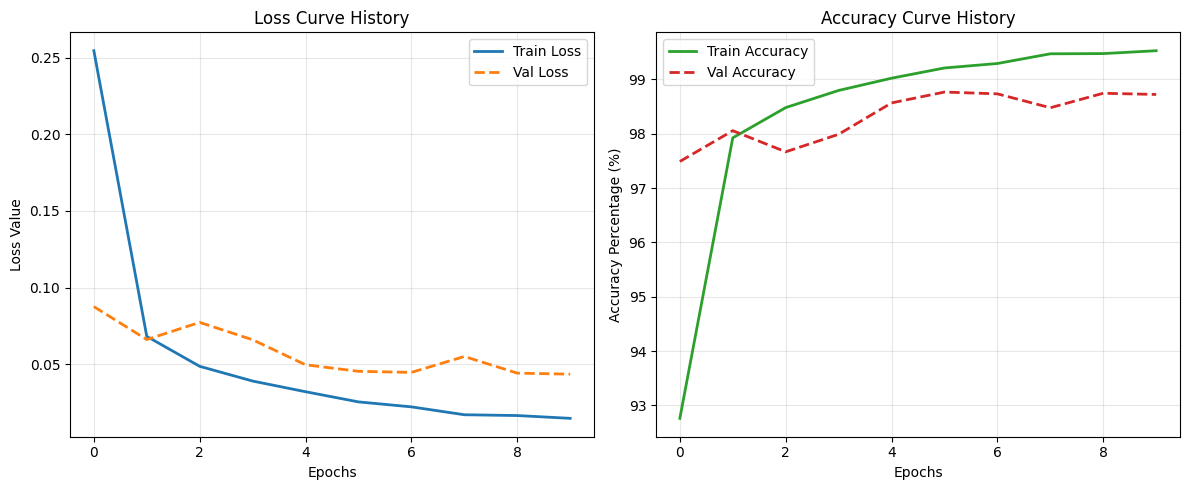

In [6]:
# Step 6: Plot Loss and Accuracy histories
plt.figure(figsize=(12, 5))

# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, linestyle='--')
plt.title('Loss Curve History')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='#2ca02c', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', color='#d62728', lw=2, linestyle='--')
plt.title('Accuracy Curve History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Percentage (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Model Evaluation on Unseen Test Set

In [7]:
# Step 7: Evaluate generalization capabilities on held-out test configurations
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
print(f"=== Final Evaluation Performance ===")
print(f"Test Loss Dimension: {test_loss:.4f}")
print(f"Test Class Accuracy : {test_acc:.2f}%")

=== Final Evaluation Performance ===
Test Loss Dimension: 0.0335
Test Class Accuracy : 98.90%


## Visualizing Sample Predictions
Let's pull a random batch from our test data pipeline to visually verify model classification inferences against ground truth data configurations.

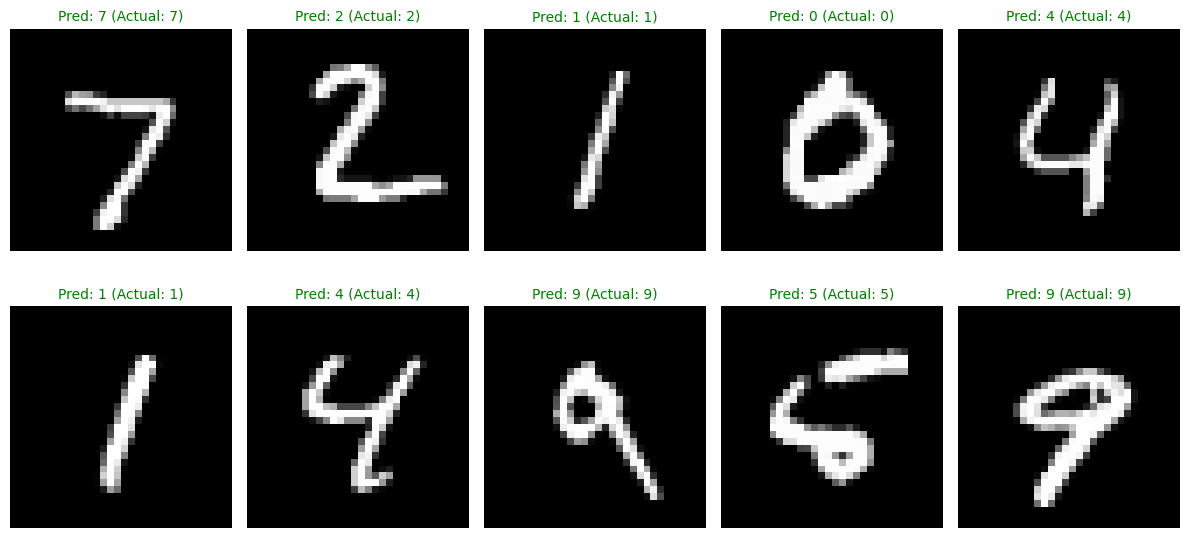

In [8]:
# Step 8: Plot inference predictions out of actual dataset runs
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = outputs.max(1)

# Convert image batches to displayable numpy structures
images = images.cpu().numpy()
labels = labels.cpu().numpy()
preds = preds.cpu().numpy()

# Set up canvas layout grid
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for idx in range(10):
    # Un-normalize values to recover original display arrays
    img = images[idx].squeeze() * 0.3081 + 0.1307
    
    axes[idx].imshow(img, cmap='gray')
    color = 'green' if preds[idx] == labels[idx] else 'red'
    axes[idx].set_title(f"Pred: {preds[idx]} (Actual: {labels[idx]})", color=color, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()